In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [40]:
#raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.csv',sep=';',encoding='latin1')
raw_fuel_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\mym\1HZL.xlsx')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 27029 entries, 0 to 27028
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  27029 non-null  str  
 1   Message  27029 non-null  str  
 2   Status   27029 non-null  str  
dtypes: str(3)
memory usage: 633.6 KB


In [41]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('0x252521')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [42]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
fs01_raw_data=[]
fs02_raw_data=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs01_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs01_aux.find('3E01')
    if ((aux>47) & (aux<49)):
        fs01=(e0x_aux[48:66])
        #print(fs01,e0x.iloc[i,2])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs01=i
            fs01_raw_data.append(e0x_aux)
            
#print(i, raw_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    e0x_fs02_aux='xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx'+e0x_aux[32:]
    aux=e0x_fs02_aux.find('3E02')    
    if ((aux>47) & (aux<49)):
        fs02=e0x_aux[48:66]
        #print(fs02,aux)
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,2][32:44])
            last_index_fs02=i
            fs02_raw_data.append(e0x_aux)
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
#print('El Ncode en decimal es:')
values_dates_fs01['value']=fs01_dec_value
values_dates_fs01['date']=date_fs01_dec_value
values_dates_fs01['raw data']=fs01_raw_data
values_dates_fs02['value']=fs02_dec_value
values_dates_fs02['date']=date_fs02_dec_value
values_dates_fs02['raw data']=fs02_raw_data

values_dates_fs01_ordered=values_dates_fs01.sort_values('date',ascending=True)
values_dates_fs02_ordered=values_dates_fs02.sort_values('date',ascending=True)

values_dates_fs01_ordered.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\macu\Exportfs01.csv')
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])

Last fuel report fs01:  2026-09-04 13:08:03.728 Last fuel report fs02:  2026-09-04 13:08:03.169


In [43]:
values_dates_fs01.info()
values_dates_fs02.info()

<class 'pandas.DataFrame'>
RangeIndex: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 253.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 4447 entries, 0 to 4446
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     4447 non-null   int64
 1   date      4447 non-null   str  
 2   raw data  4447 non-null   str  
dtypes: int64(1), str(2)
memory usage: 104.4 KB


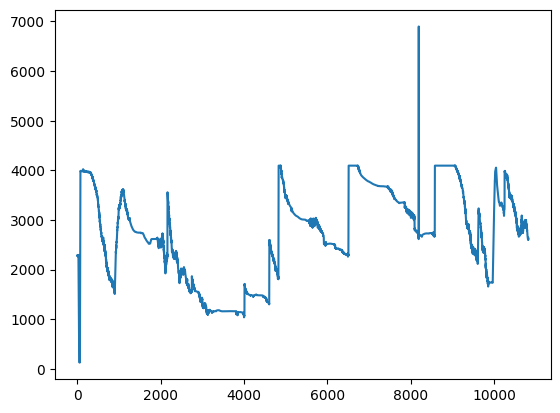

In [44]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)

plt.plot(fs01_x_values,values_dates_fs01_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

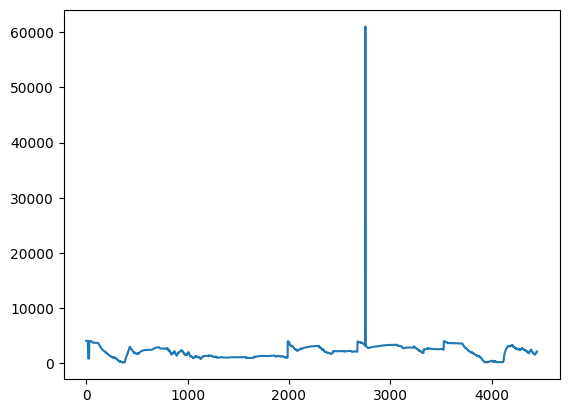

In [45]:
plt.plot(fs02_x_values,values_dates_fs02_ordered['value'])
#plt.plot(fs02_x_values,fs02_dec_value)

In [46]:
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,0])>4095:
        print(i,values_dates_fs01_ordered.iloc[i,2],'->',values_dates_fs01_ordered.iloc[1,2][32:44],values_dates_fs01_ordered.iloc[i,0])

8190 0x25252100242CF5086948706020102626083115201801013E01071FF31A3FFBFB0AEFAF3B -> 260819150030 6899


In [47]:
values_dates_fs01_ordered.info()

<class 'pandas.DataFrame'>
Index: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 338.1 KB


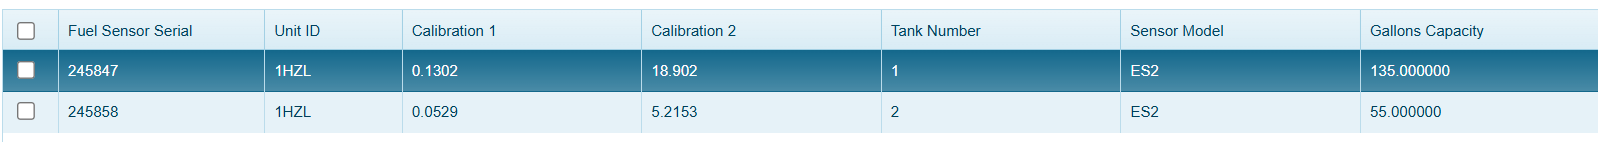

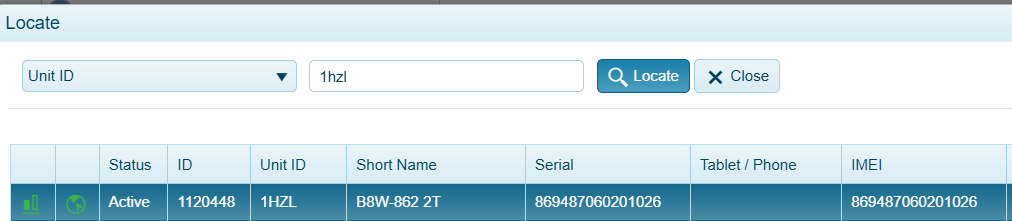

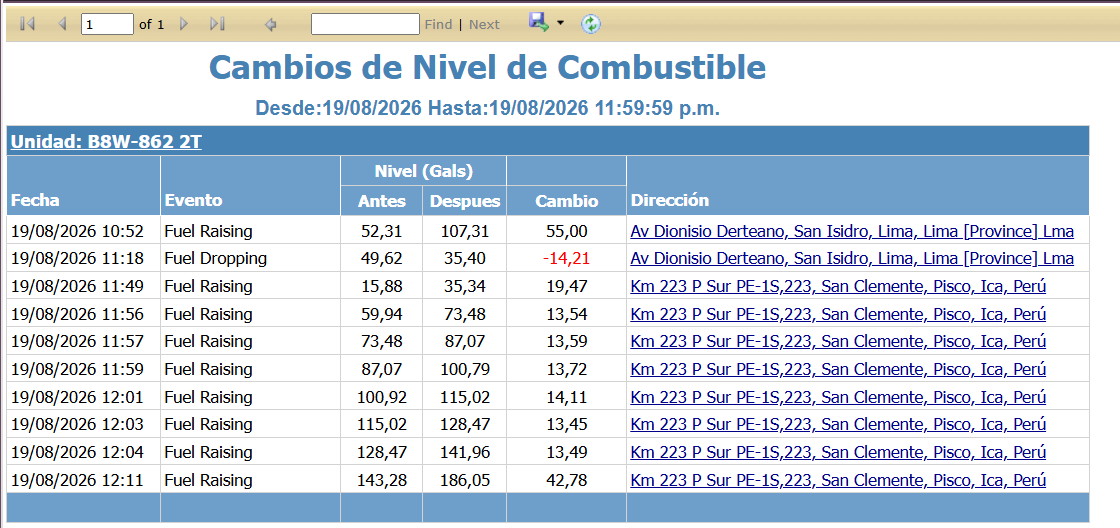

In [48]:
gallons_fs01=[]
gallons_fs02=[]
m1=0.1302
b1=18.902
m2=0.0529
b2=5.2153

values_dates_fs01_ordered.info()

for i in range(0,values_dates_fs01_ordered.shape[0]):
    gallons_value_fs01=(float(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)
    gallons_fs01.append(gallons_value_fs01) 
    print(i,values_dates_fs01_ordered.iloc[i,2][32:44],(values_dates_fs01_ordered.iloc[i,0]*m1-b1)/3.785412)

for i in range(0,values_dates_fs02_ordered.shape[0]):
    gallons_value_fs02=(float(values_dates_fs02_ordered.iloc[i,0]*m2-b2)/3.785412)
    gallons_fs02.append(gallons_value_fs02)  
    print(i,values_dates_fs02_ordered.iloc[i,2][32:44],(values_dates_fs02_ordered.iloc[i,0]*m1-b1)/3.785412)

values_dates_fs01_ordered['gallons']=gallons_fs01
values_dates_fs02_ordered['gallons']=gallons_fs02

<class 'pandas.DataFrame'>
Index: 10819 entries, 0 to 10818
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   value     10819 non-null  int64
 1   date      10819 non-null  str  
 2   raw data  10819 non-null  str  
dtypes: int64(1), str(2)
memory usage: 338.1 KB
0 260819145845 73.56525524830587
1 260819150030 73.56525524830587
2 260819150215 73.56525524830587
3 260819150400 73.56525524830587
4 260819150545 73.56525524830587
5 260819150730 73.56525524830587
6 260819150915 73.56525524830587
7 260819151100 73.56525524830587
8 260819151245 72.98053686098106
9 260819151430 73.73723124457787
10 260819151615 73.94360244010429
11 260819151800 73.97799763935869
12 260819151945 73.97799763935869
13 260819152130 73.97799763935869
14 260819152315 73.97799763935869
15 260819152500 73.94360244010429
16 260819152645 73.94360244010429
17 260819152830 73.94360244010429
18 260819153015 73.94360244010429
19 260819153200 73.94360244010429
20 26

In [49]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vahice is parked, p=0

date1=260819154000
date2=260819171251

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>=(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
        if values_dates_fs01_ordered.iloc[i+1,3]<=(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            level=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level)
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>=(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)
        if values_dates_fs02_ordered.iloc[i+1,3]<=(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            level=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level)

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta
droping 72.94614166172666 73.94360244010429 -0.9974607783776293
droping 68.61234655567216 72.94614166172666 -5.3312558844321245
droping 63.72822826154724 68.61234655567216 -10.215374178557049
droping 58.80971476816791 63.72822826154724 -15.133887671936378
droping 53.95999167329739 58.80971476816791 -19.983610766806898
droping 52.30902210908615 53.95999167329739 -21.634580331018135
droping 47.149742220926015 52.30902210908615 -26.79386021917827
droping 43.98538388952115 47.149742220926015 -29.958218550583133
droping 39.23884639241383 43.98538388952115 -34.70475604769045
droping 34.1483569027625 39.23884639241383 -39.795245537341785
droping 28.95468181534798 34.1483569027625 -44.988920624756304
droping 23.623425930915843 28.95468181534798 -50.32017650918844
droping 19.048864430080535 23.623425930915843 -54.89473801002375
droping 15.574949305386045 19.048864430080535 -58.368653134718244
droping 10.65643581

Adding the validation to delete the value that beongs to ragistger i+1.

In [50]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260819154000
date2=260819171251
level=0


print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

print("Level change toal: ",level)

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
droping 72.94614166172666 73.94360244010429 -0.9974607783776293 -0.9974607783776293
droping 68.61234655567216 72.94614166172666 -5.3312558844321245 -4.333795106054495
droping 63.72822826154724 68.61234655567216 -10.215374178557049 -4.884118294124924
droping 58.80971476816791 63.72822826154724 -15.133887671936378 -4.918513493379329
droping 53.95999167329739 58.80971476816791 -19.983610766806898 -4.8497230948705194
droping 52.30902210908615 53.95999167329739 -21.634580331018135 -1.6509695642112376
droping 47.149742220926015 52.30902210908615 -26.79386021917827 -5.159279888160135
droping 43.98538388952115 47.149742220926015 -29.958218550583133 -3.1643583314048627
droping 39.23884639241383 43.98538388952115 -34.70475604769045 -4.746537497107319
droping 34.1483569027625 39.23884639241383 -39.795245537341785 -5.090489489651333
droping 28.95468181534798 34.1483569027625 -44.988920624756304 -5.19367508

In [51]:
capacity_1=135
capacity_2=55
level=0
p=0 # If vehicle is parked, p=0

date1=260819154000
date2=260819171251
level=0

delta_aux=[]
x_after=[]
x_=[]

df_report=pd.DataFrame()

print("Tank 1: ")
print("Raising/Droping","->","end gallons","->","initial gallons","->","new_delta + old_delta","->","delta")
for i in range(0,values_dates_fs01_ordered.shape[0]):
    if int(values_dates_fs01_ordered.iloc[i,1])>=date1 and int(values_dates_fs01_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]>(values_dates_fs01_ordered.iloc[i,3]+(p/100)*capacity_1):            
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if values_dates_fs01_ordered.iloc[i+1,3]<(values_dates_fs01_ordered.iloc[i,3]-(p/100)*capacity_1):
            delta=values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs01_ordered.iloc[i+1,3],values_dates_fs01_ordered.iloc[i,3],level,values_dates_fs01_ordered.iloc[i+1,3]-values_dates_fs01_ordered.iloc[i,3])
        if int(values_dates_fs01_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs01_ordered.iloc[i+1,3]-float(values_dates_fs01_ordered.iloc[i,3]))
print("Level change tank 1: ",level)

print("Level change tank 1 + Level change tank 2: ")
for i in range(0,values_dates_fs02_ordered.shape[0]):
    if int(values_dates_fs02_ordered.iloc[i,1])>=date1 and int(values_dates_fs02_ordered.iloc[i,1])<=date2:
        #print(i,values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3])
        if values_dates_fs02_ordered.iloc[i+1,3]>(values_dates_fs02_ordered.iloc[i,3]+(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("raising",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if values_dates_fs02_ordered.iloc[i+1,3]<(values_dates_fs02_ordered.iloc[i,3]-(p/100)*capacity_2):
            delta=values_dates_fs02_ordered.iloc[i+1,3]-values_dates_fs02_ordered.iloc[i,3]
            delta_aux.append(delta)
            x_after.append(values_dates_fs01_ordered.iloc[i+1,3])
            x_.append(values_dates_fs01_ordered.iloc[i,3])
            level=delta+level
            print("droping",values_dates_fs02_ordered.iloc[i+1,3],values_dates_fs02_ordered.iloc[i,3],level,delta)
        if int(values_dates_fs02_ordered.iloc[i+1,1])>date2:
            level=level-float(values_dates_fs02_ordered.iloc[i+1,3]-float(values_dates_fs02_ordered.iloc[i,3]))

df_report['x_']=x_
df_report['x_after']=x_after
df_report['delta']=delta_aux

df_report

Tank 1: 
Raising/Droping -> end gallons -> initial gallons -> new_delta + old_delta -> delta
droping 72.94614166172666 73.94360244010429 -0.9974607783776293 -0.9974607783776293
droping 68.61234655567216 72.94614166172666 -5.3312558844321245 -4.333795106054495
droping 63.72822826154724 68.61234655567216 -10.215374178557049 -4.884118294124924
droping 58.80971476816791 63.72822826154724 -15.133887671936378 -4.918513493379329
droping 53.95999167329739 58.80971476816791 -19.983610766806898 -4.8497230948705194
droping 52.30902210908615 53.95999167329739 -21.634580331018135 -1.6509695642112376
droping 47.149742220926015 52.30902210908615 -26.79386021917827 -5.159279888160135
droping 43.98538388952115 47.149742220926015 -29.958218550583133 -3.1643583314048627
droping 39.23884639241383 43.98538388952115 -34.70475604769045 -4.746537497107319
droping 34.1483569027625 39.23884639241383 -39.795245537341785 -5.090489489651333
droping 28.95468181534798 34.1483569027625 -44.988920624756304 -5.19367508

,x_,x_after,delta
0,73.943602,72.946142,-0.997461
1,72.946142,68.612347,-4.333795
2,68.612347,63.728228,-4.884118
3,63.728228,58.809715,-4.918513
4,58.809715,53.959992,-4.849723
5,53.959992,52.309022,-1.650970
6,52.309022,47.149742,-5.159280
7,47.149742,43.985384,-3.164358
8,43.985384,39.238846,-4.746537
9,39.238846,34.148357,-5.090489
